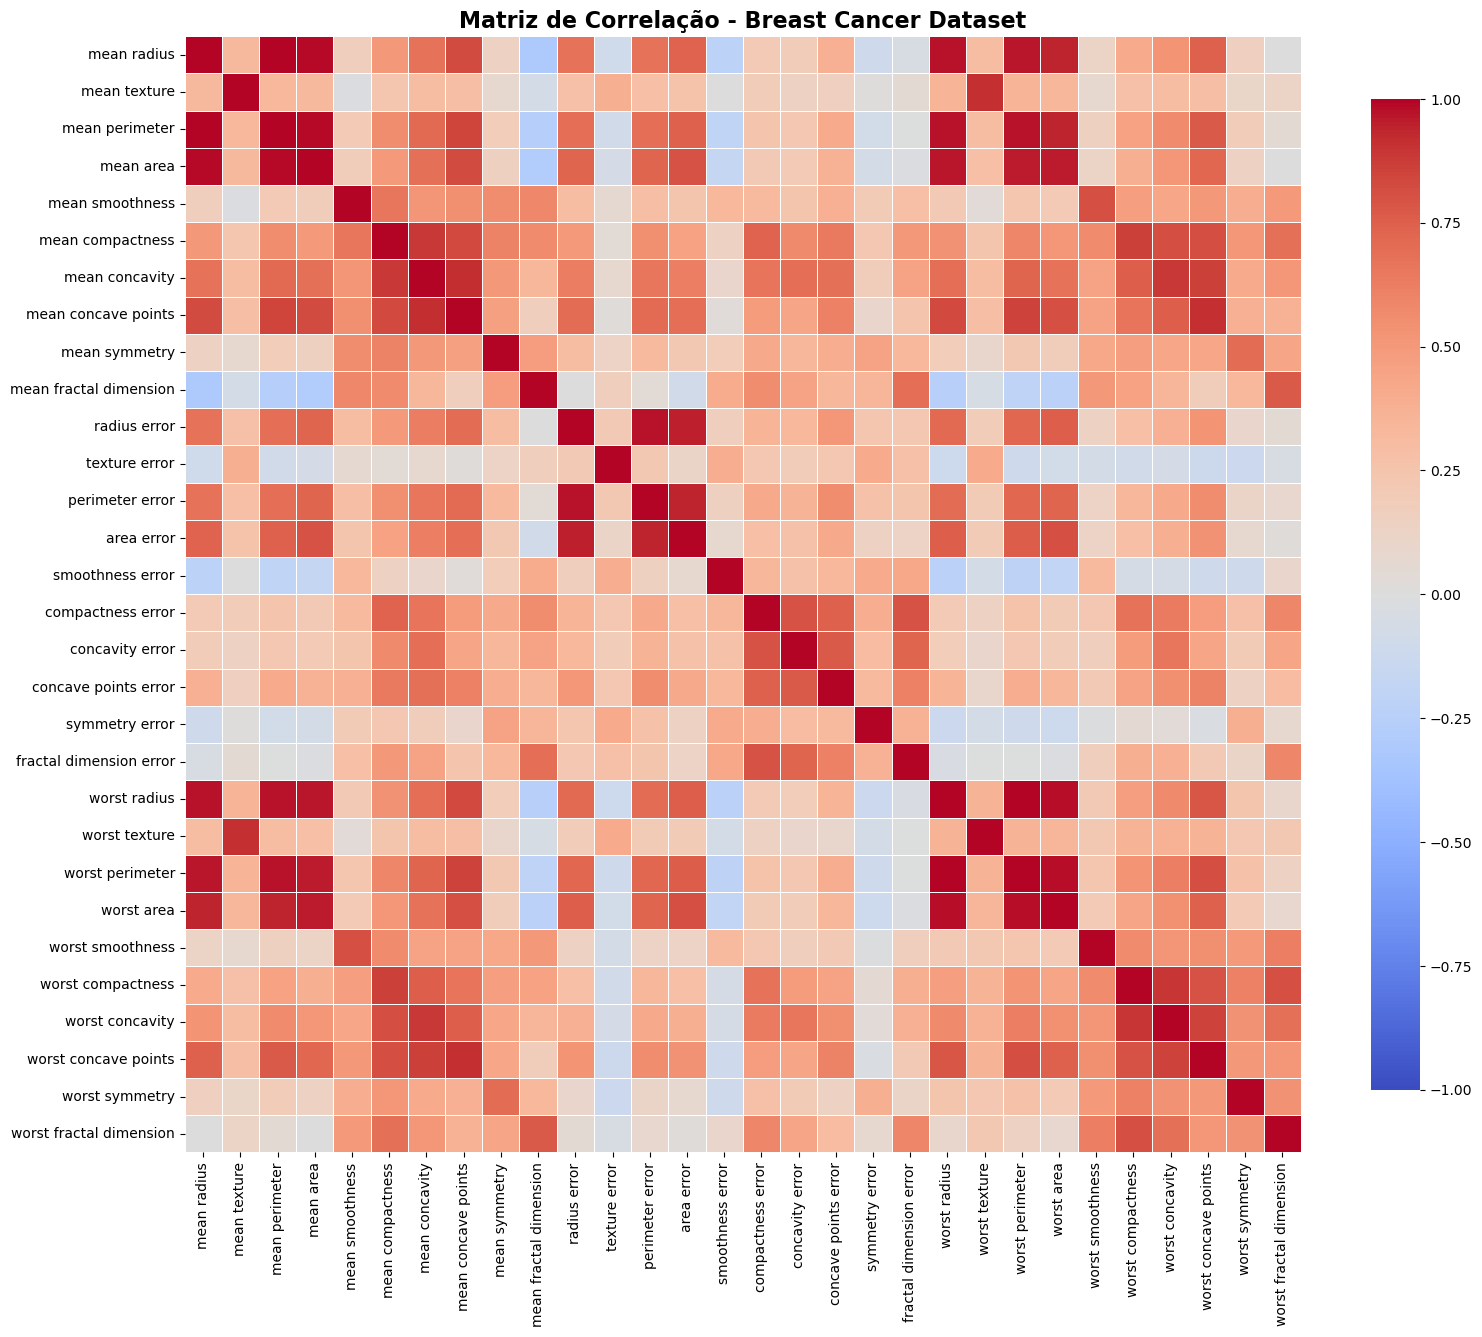

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np

# Carregar dados
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

# 1. CALCULAR MATRIZ DE CORRELAÇÃO
correlation_matrix = X.corr()

# Visualizar
plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', 
            center=0, vmin=-1, vmax=1, square=True, 
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação - Breast Cancer Dataset', 
            fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. IDENTIFICAR CORRELAÇÕES ALTAS
def find_high_correlations(correlation_matrix, threshold=0.9):
    # Criar cópia da matriz
    corr_matrix = correlation_matrix.abs()

     # Pegar apenas triângulo superior (evitar duplicatas)
    upper_triangle = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

     # Encontrar pares com alta correlação
    high_corr_pairs = []
